# Step 1: Data Collection and Understanding

In [39]:
import pandas as pd
import yfinance as yf

# Download Stock Data

ticker = "RELIANCE.NS"

data = yf.download(
    ticker,
    start="2020-01-01",
    interval="1d",
    auto_adjust=False
)

# Flatten MultiIndex Columns

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Save Raw Dataset

data.to_csv("nse_ohlcv_raw.csv")

# Load Dataset

data = pd.read_csv("nse_ohlcv_raw.csv")

# Data Understanding

print("\nFirst 5 Rows")
print(data.head())

print("\nLast 5 Rows")
print(data.tail())

print("\nDataset Information")
data.info()

print("\nStatistical Summary")
print(data.describe())

print("\nColumn Names")
print(data.columns.tolist())

print("\nDataset Shape")
print(data.shape)

print("\nData Types")
print(data.dtypes)

[*********************100%***********************]  1 of 1 completed


First 5 Rows
         Date   Adj Close       Close        High         Low        Open  \
0  2020-01-01  672.216125  690.138306  698.138733  688.263977  693.978516   
1  2020-01-02  683.660278  701.887512  704.470520  691.235535  691.235535   
2  2020-01-03  684.484009  702.733276  704.790527  696.264343  700.835999   
3  2020-01-06  668.609253  686.435303  698.504456  684.835205  694.892883   
4  2020-01-07  678.895569  696.995850  701.521790  691.921265  694.435669   

     Volume  
0  14004468  
1  17710316  
2  20984698  
3  24519177  
4  16683622  

Last 5 Rows
            Date    Adj Close        Close         High          Low  \
1658  2026-09-07  1309.500000  1309.500000  1324.199951  1301.900024   
1659  2026-09-08  1294.900024  1294.900024  1306.800049  1288.000000   
1660  2026-09-09  1279.000000  1279.000000  1294.699951  1277.199951   
1661  2026-09-10  1274.000000  1274.000000  1285.300049  1266.300049   
1662  2026-09-11  1257.500000  1257.500000  1267.400024  1253.0000

# Step 2: Data Preprocessing

In [40]:

# Check Missing Values

print("\nMissing Values")
print(data.isnull().sum())

# Check Duplicate Rows

print("\nDuplicate Rows")
print(data.duplicated().sum())

# Convert Date Column to Datetime

data["Date"] = pd.to_datetime(data["Date"])

# Sort Data by Date

data = data.sort_values("Date")

# Remove Missing Values

data = data.dropna()

# Remove Duplicate Rows

data = data.drop_duplicates()

# Reset Index

data = data.reset_index(drop=True)

# Verify Dataset After Cleaning

print("\nAfter Cleaning")

print("\nMissing Values")
print(data.isnull().sum())

print("\nDuplicate Rows")
print(data.duplicated().sum())

print("\nDataset Shape")
print(data.shape)

# =====================================================
# FORMAT DATA
# =====================================================

price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close"
]

for col in price_columns:

    if col in data.columns:

        data[col] = data[col].round(2)

# =====================================================
# SAVE CLEAN DATASET
# =====================================================

data.to_csv(
    "nse_ohlcv_clean.csv",
    index=False
)




Missing Values
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate Rows
0

After Cleaning

Missing Values
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate Rows
0

Dataset Shape
(1663, 7)


# Step 3: Feature Engineering


In [41]:

#Candle Body
data["Body"] = abs(data["Close"] - data["Open"])

#Total Candle Range
data["Range"] = data["High"] - data["Low"]

#Upper Wick
data["Upper_Wick"] = (
    data["High"]
    - data[["Open", "Close"]].max(axis=1)
)

#Lower Wick
data["Lower_Wick"] = (
    data[["Open", "Close"]].min(axis=1)
    - data["Low"]
)

#Ratios
data["Body_Ratio"] = data["Body"] / data["Range"]

data["Upper_Wick_Ratio"] = (
    data["Upper_Wick"] / data["Range"]
)

data["Lower_Wick_Ratio"] = (
    data["Lower_Wick"] / data["Range"]
)

#Replace infinite values if any
data.replace([float("inf"), -float("inf")], 0, inplace=True)

#Fill NaN values
data.fillna(0, inplace=True)

#Display Result
print("Feature Engineering Completed\n")

print(data[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Body",
        "Range",
        "Upper_Wick",
        "Lower_Wick"
    ]
].head())

# =====================================================
# FORMAT DATA
# =====================================================

price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Body",
    "Range",
    "Upper_Wick",
    "Lower_Wick"
]

ratio_columns = [
    "Body_Ratio",
    "Upper_Wick_Ratio",
    "Lower_Wick_Ratio"
]

for col in price_columns:

    data[col] = data[col].round(2)

for col in ratio_columns:

    data[col] = data[col].round(4)

# =====================================================
# SAVE DATASET
# =====================================================

data.to_csv(

    "candlestick_features.csv",

    index=False

)

Feature Engineering Completed

     Open    High     Low   Close   Body  Range  Upper_Wick  Lower_Wick
0  693.98  698.14  688.26  690.14   3.84   9.88        4.16        1.88
1  691.24  704.47  691.24  701.89  10.65  13.23        2.58        0.00
2  700.84  704.79  696.26  702.73   1.89   8.53        2.06        4.58
3  694.89  698.50  684.84  686.44   8.45  13.66        3.61        1.60
4  694.44  701.52  691.92  697.00   2.56   9.60        4.52        2.52


# STEP 4 : MARKET STRUCTURE AND TREND ANALYSIS


Starting Market Structure Analysis...

Pivot High Detection Completed
Pivot Low Detection Completed
HH HL LH LL Classification Completed
Trend Direction Completed
Market Control Completed
HTF Bias Completed

Trend Distribution

Trend
Uptrend      815
Downtrend    812
Sideways      36
Name: count, dtype: int64

Date : 2026-09-11 00:00:00
Trend : Downtrend
Market Control : Sellers
HTF Bias : Bearish

market_structure_analysis.csv Saved


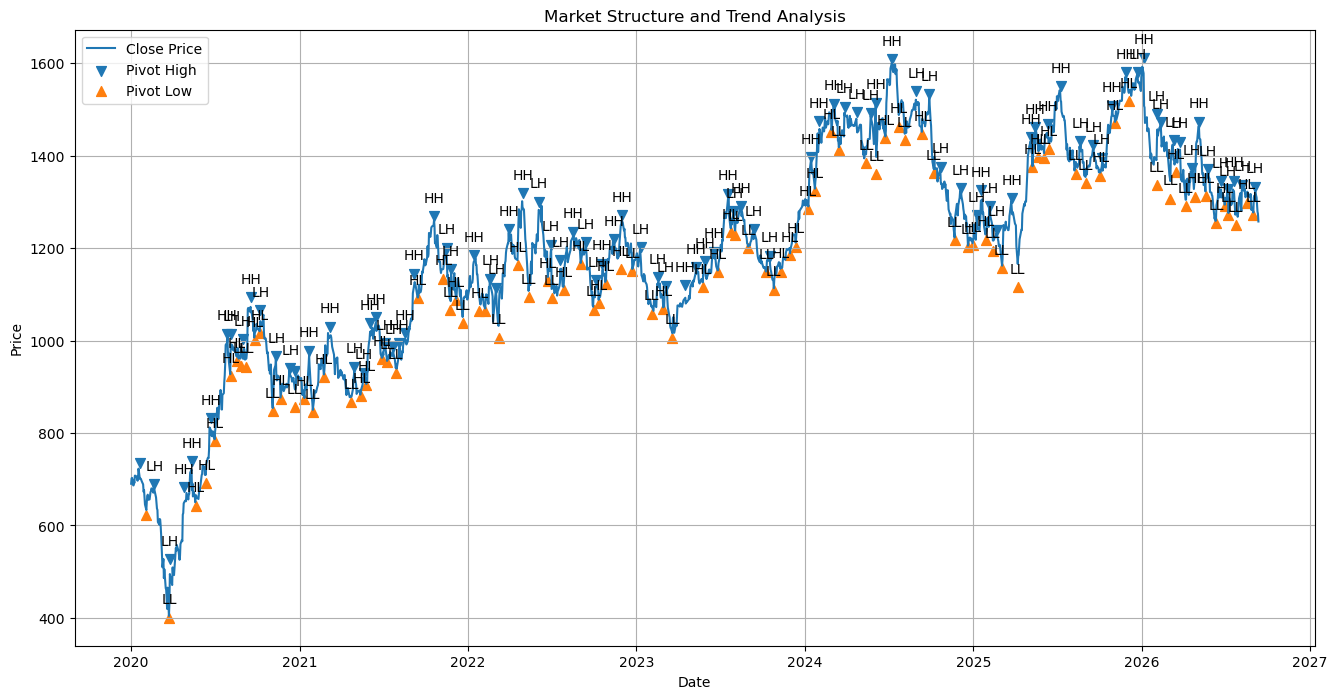

In [42]:
# =====================================================
# STEP 4 : MARKET STRUCTURE AND TREND ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

print("\nStarting Market Structure Analysis...\n")

# =====================================================
# SWING HIGH DETECTION
# =====================================================

swing_length = 5

data["PivotHigh"] = np.nan
data["PivotLow"] = np.nan

for i in range(swing_length, len(data) - swing_length):

    current_high = data["High"].iloc[i]

    left_highs = data["High"].iloc[
        i-swing_length:i
    ]

    right_highs = data["High"].iloc[
        i+1:i+swing_length+1
    ]

    if (
        current_high > left_highs.max()
        and
        current_high >= right_highs.max()
    ):
        data.loc[
            data.index[i],
            "PivotHigh"
        ] = current_high

print("Pivot High Detection Completed")

# =====================================================
# SWING LOW DETECTION
# =====================================================

for i in range(swing_length, len(data) - swing_length):

    current_low = data["Low"].iloc[i]

    left_lows = data["Low"].iloc[
        i-swing_length:i
    ]

    right_lows = data["Low"].iloc[
        i+1:i+swing_length+1
    ]

    if (
        current_low < left_lows.min()
        and
        current_low <= right_lows.min()
    ):
        data.loc[
            data.index[i],
            "PivotLow"
        ] = current_low

print("Pivot Low Detection Completed")

# =====================================================
# HH HL LH LL CLASSIFICATION
# =====================================================

data["HH"] = False
data["HL"] = False
data["LH"] = False
data["LL"] = False

data["Structure"] = ""

previous_high = np.nan
previous_low = np.nan

for i in range(len(data)):

    # ----------------------------------
    # Pivot High
    # ----------------------------------

    if not pd.isna(
        data["PivotHigh"].iloc[i]
    ):

        current_high = (
            data["PivotHigh"].iloc[i]
        )

        if not pd.isna(previous_high):

            if current_high > previous_high:

                data.loc[
                    data.index[i],
                    "HH"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "HH"

            elif current_high < previous_high:

                data.loc[
                    data.index[i],
                    "LH"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "LH"

        previous_high = current_high

    # ----------------------------------
    # Pivot Low
    # ----------------------------------

    if not pd.isna(
        data["PivotLow"].iloc[i]
    ):

        current_low = (
            data["PivotLow"].iloc[i]
        )

        if not pd.isna(previous_low):

            if current_low > previous_low:

                data.loc[
                    data.index[i],
                    "HL"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "HL"

            elif current_low < previous_low:

                data.loc[
                    data.index[i],
                    "LL"
                ] = True

                data.loc[
                    data.index[i],
                    "Structure"
                ] = "LL"

        previous_low = current_low

print("HH HL LH LL Classification Completed")

# =====================================================
# TREND DIRECTION
# =====================================================

data["Trend"] = "Sideways"

last_structure = "None"

for i in range(len(data)):

    if data["Structure"].iloc[i] != "":

        last_structure = (
            data["Structure"].iloc[i]
        )

    if last_structure in [
        "HH",
        "HL"
    ]:

        data.loc[
            data.index[i],
            "Trend"
        ] = "Uptrend"

    elif last_structure in [
        "LH",
        "LL"
    ]:

        data.loc[
            data.index[i],
            "Trend"
        ] = "Downtrend"

print("Trend Direction Completed")

# =====================================================
# MARKET CONTROL
# =====================================================

data["Market_Control"] = "Neutral"

data.loc[
    data["Trend"] == "Uptrend",
    "Market_Control"
] = "Buyers"

data.loc[
    data["Trend"] == "Downtrend",
    "Market_Control"
] = "Sellers"

print("Market Control Completed")

# =====================================================
# HTF BIAS
# =====================================================

data["EMA50"] = (
    data["Close"]
    .ewm(
        span=50,
        adjust=False
    )
    .mean()
)

data["EMA200"] = (
    data["Close"]
    .ewm(
        span=200,
        adjust=False
    )
    .mean()
)

data["HTF_Bias"] = np.where(
    data["EMA50"] >
    data["EMA200"],
    "Bullish",
    "Bearish"
)

print("HTF Bias Completed")

# =====================================================
# TREND DISTRIBUTION
# =====================================================

print("\nTrend Distribution\n")

print(
    data["Trend"]
    .value_counts()
)

# =====================================================
# LATEST MARKET STATUS
# =====================================================

latest = data.iloc[-1]

print("\n================================")

print("Date :", latest["Date"])

print(
    "Trend :",
    latest["Trend"]
)

print(
    "Market Control :",
    latest["Market_Control"]
)

print(
    "HTF Bias :",
    latest["HTF_Bias"]
)

print("================================")

# =====================================================
# FORMAT DATA
# =====================================================

price_columns = [

    "Open",
    "High",
    "Low",
    "Close",

    "Body",
    "Range",
    "Upper_Wick",
    "Lower_Wick",

    "PivotHigh",
    "PivotLow",

    "EMA50",
    "EMA200"

]

ratio_columns = [

    "Body_Ratio",
    "Upper_Wick_Ratio",
    "Lower_Wick_Ratio"

]

for col in price_columns:

    if col in data.columns:

        data[col] = data[col].round(2)

for col in ratio_columns:

    if col in data.columns:

        data[col] = data[col].round(4)

# =====================================================
# SAVE DATASET
# =====================================================

data.to_csv(
    "market_structure_analysis.csv",
    index=False
)

print(
    "\nmarket_structure_analysis.csv Saved"
)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(16, 8))

plt.plot(
    data["Date"],
    data["Close"],
    label="Close Price"
)

pivot_highs = data[
    data["PivotHigh"].notna()
]

pivot_lows = data[
    data["PivotLow"].notna()
]

plt.scatter(
    pivot_highs["Date"],
    pivot_highs["PivotHigh"],
    marker="v",
    s=50,
    label="Pivot High"
)

plt.scatter(
    pivot_lows["Date"],
    pivot_lows["PivotLow"],
    marker="^",
    s=50,
    label="Pivot Low"
)

for _, row in data.iterrows():

    if row["Structure"] != "":

        y = (
            row["High"]
            if row["Structure"]
            in ["HH", "LH"]
            else row["Low"]
        )

        plt.annotate(
            row["Structure"],
            (row["Date"], y),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center"
        )

plt.title(
    "Market Structure and Trend Analysis"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

# Step 5: Candlestick Pattern Recognition

In [43]:


# =====================================================
# HAMMER
# =====================================================

data["Hammer"] = np.where(

    (
        (data["Lower_Wick"] >= 2 * data["Body"])
        &
        (data["Upper_Wick"] <= data["Body"])
        &
        (data["Body_Ratio"] <= 0.5)
    ),

    1,

    0

)

# =====================================================
# INVERTED HAMMER
# =====================================================

data["Inverted_Hammer"] = np.where(

    (
        (data["Upper_Wick"] >= 2 * data["Body"])
        &
        (data["Lower_Wick"] <= data["Body"])
        &
        (data["Body_Ratio"] <= 0.5)
    ),

    1,

    0

)

# =====================================================
# DOJI
# =====================================================

data["Doji"] = np.where(

    data["Body_Ratio"] <= 0.1,

    1,

    0

)

# =====================================================
# BULLISH ENGULFING
# =====================================================

data["Bullish_Engulfing"] = np.where(

    (
        (data["Close"].shift(1) < data["Open"].shift(1))
        &
        (data["Close"] > data["Open"])
        &
        (data["Open"] < data["Close"].shift(1))
        &
        (data["Close"] > data["Open"].shift(1))
    ),

    1,

    0

)

# =====================================================
# BEARISH ENGULFING
# =====================================================

data["Bearish_Engulfing"] = np.where(

    (
        (data["Close"].shift(1) > data["Open"].shift(1))
        &
        (data["Close"] < data["Open"])
        &
        (data["Open"] > data["Close"].shift(1))
        &
        (data["Close"] < data["Open"].shift(1))
    ),

    1,

    0

)

# =====================================================
# SHOOTING STAR
# =====================================================

data["Shooting_Star"] = np.where(

    (
        (data["Upper_Wick"] >= 2 * data["Body"])
        &
        (data["Lower_Wick"] <= data["Body"] * 0.5)
        &
        (data["Body_Ratio"] <= 0.5)
    ),

    1,

    0

)

# =====================================================
# MORNING STAR
# =====================================================

data["Morning_Star"] = np.where(

    (
        (data["Close"].shift(2) < data["Open"].shift(2))
        &
        (data["Body"].shift(1) <
         data["Body"].shift(2))
        &
        (data["Close"] > data["Open"])
    ),

    1,

    0

)

# =====================================================
# EVENING STAR
# =====================================================

data["Evening_Star"] = np.where(

    (
        (data["Close"].shift(2) > data["Open"].shift(2))
        &
        (data["Body"].shift(1) <
         data["Body"].shift(2))
        &
        (data["Close"] < data["Open"])
    ),

    1,

    0

)

# =====================================================
# PATTERN SUMMARY
# =====================================================

print("\nPattern Counts\n")

print("Hammer :", data["Hammer"].sum())

print(
    "Inverted Hammer :",
    data["Inverted_Hammer"].sum()
)

print(
    "Doji :",
    data["Doji"].sum()
)

print(
    "Bullish Engulfing :",
    data["Bullish_Engulfing"].sum()
)

print(
    "Bearish Engulfing :",
    data["Bearish_Engulfing"].sum()
)

print(
    "Shooting Star :",
    data["Shooting_Star"].sum()
)

print(
    "Morning Star :",
    data["Morning_Star"].sum()
)

print(
    "Evening Star :",
    data["Evening_Star"].sum()
)

# =====================================================
# DISPLAY LATEST RESULTS
# =====================================================

print("\nLatest Pattern Results\n")

print(

    data[

        [

            "Date",

            "Hammer",

            "Inverted_Hammer",

            "Doji",

            "Bullish_Engulfing",

            "Bearish_Engulfing",

            "Shooting_Star",

            "Morning_Star",

            "Evening_Star"

        ]

    ].tail(20)

)

# =====================================================
# FORMAT DATA
# =====================================================

price_columns = [

    "Open",
    "High",
    "Low",
    "Close",

    "Body",
    "Range",

    "Upper_Wick",
    "Lower_Wick",

    "PivotHigh",
    "PivotLow",

    "EMA50",
    "EMA200"

]

ratio_columns = [

    "Body_Ratio",
    "Upper_Wick_Ratio",
    "Lower_Wick_Ratio"

]

for col in price_columns:

    if col in data.columns:

        data[col] = data[col].round(2)

for col in ratio_columns:

    if col in data.columns:

        data[col] = data[col].round(4)

# =====================================================
# SAVE DATASET
# =====================================================

data.to_csv(

    "candlestick_pattern_dataset.csv",

    index=False

)



Pattern Counts

Hammer : 51
Inverted Hammer : 59
Doji : 175
Bullish Engulfing : 44
Bearish Engulfing : 82
Shooting Star : 23
Morning Star : 209
Evening Star : 216

Latest Pattern Results

           Date  Hammer  Inverted_Hammer  Doji  Bullish_Engulfing  \
1643 2026-08-17       0                0     1                  0   
1644 2026-08-18       0                0     0                  0   
1645 2026-08-19       0                0     0                  0   
1646 2026-08-20       1                0     0                  0   
1647 2026-08-21       1                0     0                  0   
1648 2026-08-24       0                0     0                  0   
1649 2026-08-25       0                0     0                  1   
1650 2026-08-26       0                0     0                  0   
1651 2026-08-27       0                0     0                  0   
1652 2026-08-28       0                0     0                  0   
1653 2026-08-31       0                0     1      

# Step 6: Trend Reversal Identification

In [44]:

# =====================================================
# PREVIOUS TREND
# =====================================================

data["Previous_Trend"] = (
    data["Trend"].shift(1)
)

# =====================================================
# REVERSAL COLUMN
# =====================================================

data["Trend_Reversal"] = "No Reversal"

# =====================================================
# DOWNTREND -> UPTREND
# =====================================================

data.loc[

    (
        (data["Previous_Trend"] == "Downtrend")
        &
        (data["Trend"] == "Uptrend")
    ),

    "Trend_Reversal"

] = "Bullish Reversal"

# =====================================================
# UPTREND -> DOWNTREND
# =====================================================

data.loc[

    (
        (data["Previous_Trend"] == "Uptrend")
        &
        (data["Trend"] == "Downtrend")
    ),

    "Trend_Reversal"

] = "Bearish Reversal"

# =====================================================
# SIDEWAYS -> UPTREND
# =====================================================

data.loc[

    (
        (data["Previous_Trend"] == "Sideways")
        &
        (data["Trend"] == "Uptrend")
    ),

    "Trend_Reversal"

] = "Bullish Breakout"

# =====================================================
# SIDEWAYS -> DOWNTREND
# =====================================================

data.loc[

    (
        (data["Previous_Trend"] == "Sideways")
        &
        (data["Trend"] == "Downtrend")
    ),

    "Trend_Reversal"

] = "Bearish Breakdown"

# =====================================================
# REVERSAL CONFIRMATION USING PATTERNS
# =====================================================

data["Reversal_Confirmed"] = "No"

# Bullish Confirmation

bullish_patterns = (

    (data["Hammer"] == 1)

    |

    (data["Bullish_Engulfing"] == 1)

    |

    (data["Morning_Star"] == 1)

)

# Bearish Confirmation

bearish_patterns = (

    (data["Shooting_Star"] == 1)

    |

    (data["Bearish_Engulfing"] == 1)

    |

    (data["Evening_Star"] == 1)

)

data.loc[

    (
        data["Trend_Reversal"]
        ==
        "Bullish Reversal"
    )
    &
    bullish_patterns,

    "Reversal_Confirmed"

] = "Yes"

data.loc[

    (
        data["Trend_Reversal"]
        ==
        "Bearish Reversal"
    )
    &
    bearish_patterns,

    "Reversal_Confirmed"

] = "Yes"

# =====================================================
# REVERSAL COUNTS
# =====================================================

print("\nReversal Distribution\n")

print(
    data["Trend_Reversal"]
    .value_counts()
)

# =====================================================
# DISPLAY REVERSALS ONLY
# =====================================================

reversals = data[

    data["Trend_Reversal"]
    !=
    "No Reversal"

]

print("\nDetected Reversals\n")

print(

    reversals[

        [

            "Date",

            "Previous_Trend",

            "Trend",

            "Trend_Reversal",

            "Reversal_Confirmed"

        ]

    ]

)

## =====================================================
# FORMAT DATA
# =====================================================

price_columns = [

    "Open",
    "High",
    "Low",
    "Close",

    "Body",
    "Range",

    "Upper_Wick",
    "Lower_Wick",

    "PivotHigh",
    "PivotLow",

    "EMA50",
    "EMA200"

]

ratio_columns = [

    "Body_Ratio",
    "Upper_Wick_Ratio",
    "Lower_Wick_Ratio"

]

for col in price_columns:

    if col in data.columns:

        data[col] = data[col].round(2)

for col in ratio_columns:

    if col in data.columns:

        data[col] = data[col].round(4)

# =====================================================
# SAVE DATASET
# =====================================================

data.to_csv(
    "trend_reversal_dataset.csv",
    index=False
)



Reversal Distribution

Trend_Reversal
No Reversal          1592
Bullish Reversal       35
Bearish Reversal       35
Bearish Breakdown       1
Name: count, dtype: int64

Detected Reversals

           Date Previous_Trend      Trend     Trend_Reversal  \
36   2020-02-20       Sideways  Downtrend  Bearish Breakdown   
76   2020-04-24      Downtrend    Uptrend   Bullish Reversal   
147  2020-08-05        Uptrend  Downtrend   Bearish Reversal   
155  2020-08-17      Downtrend    Uptrend   Bullish Reversal   
162  2020-08-26        Uptrend  Downtrend   Bearish Reversal   
...         ...            ...        ...                ...   
1614 2026-07-07        Uptrend  Downtrend   Bearish Reversal   
1623 2026-07-20      Downtrend    Uptrend   Bullish Reversal   
1627 2026-07-24        Uptrend  Downtrend   Bearish Reversal   
1643 2026-08-17      Downtrend    Uptrend   Bullish Reversal   
1653 2026-08-31        Uptrend  Downtrend   Bearish Reversal   

     Reversal_Confirmed  
36             

# STEP 7 : MACHINE LEARNING DATASET PREPARATION

In [45]:
# =====================================================
# STEP 7 : ML DATASET PREPARATION
# =====================================================

print("\nPreparing ML Dataset...\n")

# =====================================================
# PREVIOUS 1 CANDLE FEATURES
# =====================================================

data["Open_1"] = data["Open"].shift(1)
data["High_1"] = data["High"].shift(1)
data["Low_1"] = data["Low"].shift(1)
data["Close_1"] = data["Close"].shift(1)

data["Body_1"] = data["Body"].shift(1)
data["Range_1"] = data["Range"].shift(1)

data["Upper_Wick_1"] = data["Upper_Wick"].shift(1)
data["Lower_Wick_1"] = data["Lower_Wick"].shift(1)

data["Body_Ratio_1"] = data["Body_Ratio"].shift(1)
data["Upper_Wick_Ratio_1"] = data["Upper_Wick_Ratio"].shift(1)
data["Lower_Wick_Ratio_1"] = data["Lower_Wick_Ratio"].shift(1)

# =====================================================
# PREVIOUS 2 CANDLE FEATURES
# =====================================================

data["Open_2"] = data["Open"].shift(2)
data["High_2"] = data["High"].shift(2)
data["Low_2"] = data["Low"].shift(2)
data["Close_2"] = data["Close"].shift(2)

data["Body_2"] = data["Body"].shift(2)
data["Range_2"] = data["Range"].shift(2)

data["Upper_Wick_2"] = data["Upper_Wick"].shift(2)
data["Lower_Wick_2"] = data["Lower_Wick"].shift(2)

data["Body_Ratio_2"] = data["Body_Ratio"].shift(2)
data["Upper_Wick_Ratio_2"] = data["Upper_Wick_Ratio"].shift(2)
data["Lower_Wick_Ratio_2"] = data["Lower_Wick_Ratio"].shift(2)

# =====================================================
# REMOVE ONLY SHIFT ROWS
# =====================================================

data = data.iloc[2:].reset_index(drop=True)

# Fill remaining NaN values
data = data.fillna(0)

# =====================================================
# FEATURE COLUMNS
# =====================================================

feature_columns = [

    "Open",
    "High",
    "Low",
    "Close",
    "Volume",

    "Body",
    "Range",
    "Upper_Wick",
    "Lower_Wick",

    "Body_Ratio",
    "Upper_Wick_Ratio",
    "Lower_Wick_Ratio",

    "Open_1",
    "High_1",
    "Low_1",
    "Close_1",

    "Body_1",
    "Range_1",

    "Upper_Wick_1",
    "Lower_Wick_1",

    "Body_Ratio_1",
    "Upper_Wick_Ratio_1",
    "Lower_Wick_Ratio_1",

    "Open_2",
    "High_2",
    "Low_2",
    "Close_2",

    "Body_2",
    "Range_2",

    "Upper_Wick_2",
    "Lower_Wick_2",

    "Body_Ratio_2",
    "Upper_Wick_Ratio_2",
    "Lower_Wick_Ratio_2"

]

# =====================================================
# TARGET COLUMNS
# =====================================================

target_columns = [

    "Hammer",
    "Inverted_Hammer",
    "Doji",
    "Bullish_Engulfing",
    "Bearish_Engulfing",
    "Shooting_Star",
    "Morning_Star",
    "Evening_Star"

]

# =====================================================
# CREATE ML DATASET
# =====================================================

ml_dataset = data[
    feature_columns +
    target_columns
]

# =====================================================
# ROUND VALUES
# =====================================================

ml_dataset = ml_dataset.round(4)

# =====================================================
# DATASET INFO
# =====================================================

print("\nDataset Shape")
print(ml_dataset.shape)

print("\nFeature Count")
print(len(feature_columns))

print("\nTarget Count")
print(len(target_columns))

# =====================================================
# PATTERN DISTRIBUTION
# =====================================================

print("\nPattern Distribution\n")

for pattern in target_columns:

    print(
        pattern,
        ":",
        int(ml_dataset[pattern].sum())
    )

# =====================================================
# SAVE DATASET
# =====================================================

ml_dataset.to_csv(
    "multi_pattern_ml_dataset.csv",
    index=False
)

print(
    "\nmulti_pattern_ml_dataset.csv Saved Successfully"
)

# =====================================================
# PREVIEW
# =====================================================

print("\nFirst 5 Rows\n")

print(
    ml_dataset.head()
)


Preparing ML Dataset...


Dataset Shape
(1661, 42)

Feature Count
34

Target Count
8

Pattern Distribution

Hammer : 51
Inverted_Hammer : 59
Doji : 175
Bullish_Engulfing : 44
Bearish_Engulfing : 82
Shooting_Star : 23
Morning_Star : 209
Evening_Star : 216

multi_pattern_ml_dataset.csv Saved Successfully

First 5 Rows

     Open    High     Low   Close    Volume  Body  Range  Upper_Wick  \
0  700.84  704.79  696.26  702.73  20984698  1.89   8.53        2.06   
1  694.89  698.50  684.84  686.44  24519177  8.45  13.66        3.61   
2  694.44  701.52  691.92  697.00  16683622  2.56   9.60        4.52   
3  692.61  701.50  690.32  691.76  16047902  0.85  11.18        8.89   
4  703.40  708.61  700.04  707.69  14982742  4.29   8.57        0.92   

   Lower_Wick  Body_Ratio  ...  Upper_Wick_Ratio_2  Lower_Wick_Ratio_2  \
0        4.58      0.2216  ...              0.4211              0.1903   
1        1.60      0.6186  ...              0.1950              0.0000   
2        2.52      0.2667

In [46]:
print(ml_dataset.shape)

(1661, 42)


In [47]:
print(ml_dataset[
[
"Hammer",
"Inverted_Hammer",
"Doji",
"Bullish_Engulfing",
"Bearish_Engulfing",
"Shooting_Star",
"Morning_Star",
"Evening_Star"
]
].sum())

Hammer                51
Inverted_Hammer       59
Doji                 175
Bullish_Engulfing     44
Bearish_Engulfing     82
Shooting_Star         23
Morning_Star         209
Evening_Star         216
dtype: int64
